In [1]:
import sys
print(sys.executable)

C:\Users\Jaren\AppData\Local\Programs\Python\Python311\python.exe


Matplotlib is building the font cache; this may take a moment.


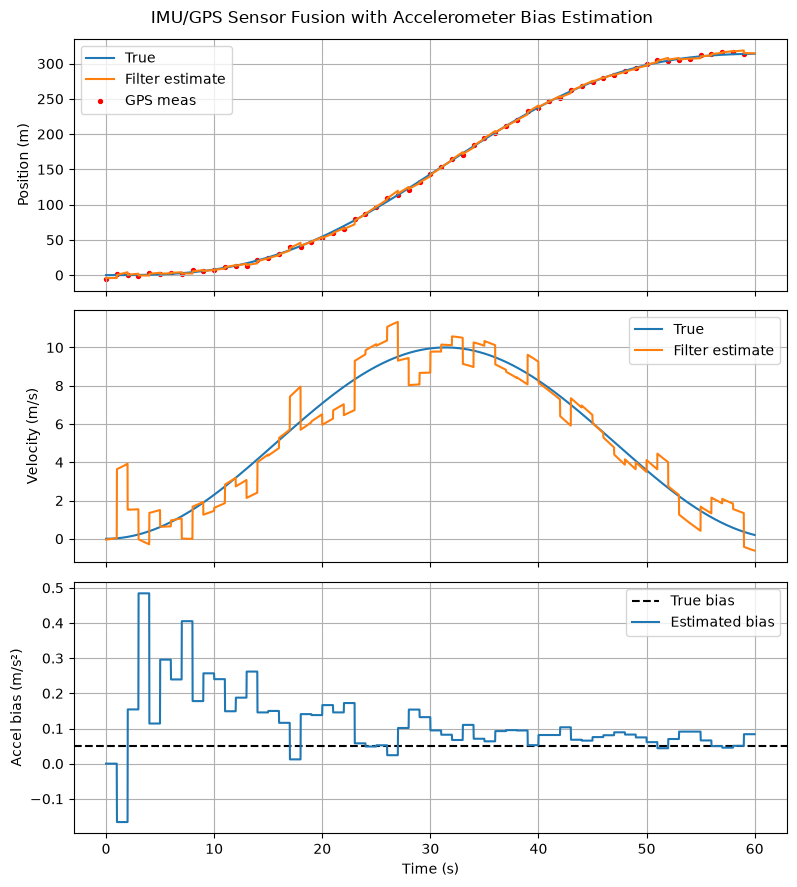

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# --- True trajectory ---
dt_imu = 0.01     # 100 Hz IMU
T = 60.0
n_imu = int(T / dt_imu)
t_imu = np.arange(n_imu) * dt_imu

true_accel = 0.5 * np.sin(0.1 * t_imu)
true_vel = np.cumsum(true_accel) * dt_imu
true_pos = np.cumsum(true_vel) * dt_imu

# --- Simulate IMU: true accel + constant bias + noise ---
accel_bias_true = 0.05
accel_noise_std = 0.02
imu_meas = true_accel + accel_bias_true + np.random.normal(0, accel_noise_std, n_imu)

# --- Simulate GPS: 1 Hz, noisy position ---
gps_rate = 1.0
step = int(1 / dt_imu / gps_rate)
gps_indices = np.arange(0, n_imu, step)
gps_noise_std = 2.0
gps_meas = {i: true_pos[i] + np.random.normal(0, gps_noise_std) for i in gps_indices}

# --- Filter state: [position, velocity, accel_bias] ---
x = np.array([0., 0., 0.])
P = np.diag([10., 10., 1.])
Q = np.diag([0.001, 0.01, 1e-6])   # process noise
R_gps = np.array([[gps_noise_std**2]])

pos_est, vel_est, bias_est = [], [], []

for i in range(n_imu):
    a_meas = imu_meas[i]

    # --- Predict using IMU ---
    F = np.array([
        [1, dt_imu, -0.5*dt_imu**2],
        [0, 1, -dt_imu],
        [0, 0, 1]
    ])
    B = np.array([0.5*dt_imu**2, dt_imu, 0])
    x = F @ x + B * a_meas
    P = F @ P @ F.T + Q

    # --- Correct using GPS when available ---
    if i in gps_meas:
        H = np.array([[1, 0, 0]])
        z = np.array([gps_meas[i]])
        y = z - H @ x
        S = H @ P @ H.T + R_gps
        K = P @ H.T @ np.linalg.inv(S)
        x = x + (K @ y)
        P = (np.eye(3) - K @ H) @ P

    pos_est.append(x[0]); vel_est.append(x[1]); bias_est.append(x[2])

gps_t = [k * dt_imu for k in gps_meas]
gps_vals = list(gps_meas.values())

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
axs[0].plot(t_imu, true_pos, label='True')
axs[0].plot(t_imu, pos_est, label='Filter estimate')
axs[0].scatter(gps_t, gps_vals, s=8, color='red', label='GPS meas')
axs[0].set_ylabel('Position (m)'); axs[0].legend(); axs[0].grid(True)

axs[1].plot(t_imu, true_vel, label='True')
axs[1].plot(t_imu, vel_est, label='Filter estimate')
axs[1].set_ylabel('Velocity (m/s)'); axs[1].legend(); axs[1].grid(True)

axs[2].axhline(accel_bias_true, color='k', linestyle='--', label='True bias')
axs[2].plot(t_imu, bias_est, label='Estimated bias')
axs[2].set_ylabel('Accel bias (m/s²)'); axs[2].set_xlabel('Time (s)')
axs[2].legend(); axs[2].grid(True)

fig.suptitle('IMU/GPS Sensor Fusion with Accelerometer Bias Estimation')
plt.tight_layout()
plt.show()